# Reference concordance: benchmarking the AON clusters against the Allen ABC Atlas

The in-house clustering (`02_clustering.ipynb`) assigns each cluster an excitatory/inhibitory
identity from marker panels. This notebook checks that annotation against an independent published
reference, the Allen Brain Cell (ABC) Atlas, by transferring ABC cell-type labels onto the
in-house clusters and measuring agreement.

The ABC Atlas is a standardized external reference already used elsewhere in this project. The
original Seurat run saved no per-cell cluster labels, so a direct cluster-to-cluster comparison
with it is not possible. The benchmark validates the **neurotransmitter / broad cell-class**
annotation, not a one-to-one match to the original's clusters.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import yaml
from scipy.stats import spearmanr
from sklearn.metrics import adjusted_rand_score

ROOT = Path("..")
with open(ROOT / "config/config.yaml") as fh:
    cfg = yaml.safe_load(fh)
paths = cfg["paths"]

AON = ROOT / paths["aon_preprocessed"]
ALLEN_10X_META = ROOT / paths["allen_10x_meta"]
ALLEN_LOG2 = ROOT / paths["allen_log2_matrix"]

OUTPUT_DIR = ROOT / paths["results_dir"]
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR = OUTPUT_DIR / "figures_raw"
TAB_DIR = OUTPUT_DIR / "tables"
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)

In [2]:
import plotting_style as ps

ps.apply_style()

## Load the in-house clustering

The 22-cluster object with log-normalized expression, Leiden labels, and the excitatory /
inhibitory annotation. The 2,000 highly variable genes are the features used for the comparison.

In [3]:
adata = sc.read_h5ad(AON)
hvg = adata.var_names[adata.var["highly_variable"]].tolist()
print(f"In-house: {adata.n_obs} nuclei, {adata.obs['leiden'].nunique()} clusters, {len(hvg)} HVGs")

In-house: 32952 nuclei, 22 clusters, 2000 HVGs


## Load the ABC Atlas OLF reference

The 10x v2 olfactory-areas (OLF) expression matrix, with per-cell class / subclass /
neurotransmitter labels joined from the ABC cell metadata. Cells without a neurotransmitter or
subclass label are dropped.

In [4]:
# per-cell labels: chunked read filtered to the OLF region (avoids loading the full 1.5 GB table)
label_cols = ["cell_label", "neurotransmitter", "class", "subclass", "region_of_interest_acronym"]
parts = []
for chunk in pd.read_csv(ALLEN_10X_META,
                         usecols=label_cols, chunksize=500_000, dtype=str):
    parts.append(chunk[chunk["region_of_interest_acronym"] == "OLF"])
meta = pd.concat(parts).drop(columns=["region_of_interest_acronym"]).set_index("cell_label")

ref = sc.read_h5ad(ALLEN_LOG2)
ref.var_names = ref.var["gene_symbol"].astype(str).values
ref.var_names_make_unique()

ref = ref[ref.obs_names.intersection(meta.index)].copy()
for col in ["neurotransmitter", "class", "subclass"]:
    ref.obs[col] = meta.loc[ref.obs_names, col].values
ref = ref[ref.obs["neurotransmitter"].notna() & ref.obs["subclass"].notna()].copy()
print(f"ABC OLF reference: {ref.n_obs} labeled cells")
print(ref.obs["neurotransmitter"].value_counts())

ABC OLF reference: 171284 labeled cells
neurotransmitter
Glut         107393
GABA          62691
Dopa           1124
Glut-GABA        75
GABA-Glyc         1
Name: count, dtype: int64


## Map each cluster to its closest ABC subclass

Each in-house cluster and each ABC subclass is reduced to a mean expression profile over the
shared highly variable genes. Clusters are matched to subclasses by **Spearman** rank correlation
of these profiles, which is invariant to the different normalizations of the two datasets (the
in-house data is `log1p` of median-normalized counts, the ABC matrix is log2). Subclasses with
fewer than 50 reference cells are dropped as noisy.

In [5]:
def mean_profiles(ad_obj, groupby, genes):
    """Mean expression over the given genes, averaged per group."""
    sub = ad_obj[:, genes]
    mat = sub.X.toarray() if hasattr(sub.X, "toarray") else np.asarray(sub.X)
    frame = pd.DataFrame(mat, columns=genes, index=ad_obj.obs_names)
    frame[groupby] = ad_obj.obs[groupby].values
    return frame.groupby(groupby, observed=True).mean()


shared = [g for g in hvg if g in set(ref.var_names)]
q_prof = mean_profiles(adata, "leiden", shared)
r_prof = mean_profiles(ref, "subclass", shared)
keep = ref.obs["subclass"].value_counts()
r_prof = r_prof.loc[r_prof.index.isin(keep[keep >= 50].index)]
print(f"{len(shared)} shared genes | {q_prof.shape[0]} clusters vs {r_prof.shape[0]} ABC subclasses")

corr = pd.DataFrame(index=q_prof.index, columns=r_prof.index, dtype=float)
for ci in q_prof.index:
    for sj in r_prof.index:
        corr.loc[ci, sj] = spearmanr(q_prof.loc[ci].values, r_prof.loc[sj].values).correlation
corr = corr.astype(float)

sub_nt = ref.obs.groupby("subclass", observed=True)["neurotransmitter"].agg(lambda s: s.mode().iloc[0])
assign = pd.DataFrame({"best_subclass": corr.idxmax(axis=1), "spearman": corr.max(axis=1).round(3)})
assign["abc_neurotransmitter"] = assign["best_subclass"].map(sub_nt)
assign["inhouse_call"] = adata.obs.groupby("leiden", observed=True)["lineage"].agg(lambda s: s.mode().iloc[0])
assign["n_nuclei"] = adata.obs["leiden"].value_counts()
assign = assign.reindex(sorted(assign.index, key=int))
print(assign.to_string())

2000 shared genes | 22 clusters vs 50 ABC subclasses


                        best_subclass  spearman abc_neurotransmitter inhouse_call  n_nuclei
leiden                                                                                     
0           009 L2/3 IT PIR-ENTl Glut     0.811                 Glut   Excitatory       930
1              063 STR D1 Sema5a Gaba     0.838                 GABA   Inhibitory      2197
2                     061 STR D1 Gaba     0.832                 GABA   Inhibitory      4957
3                     062 STR D2 Gaba     0.831                 GABA   Inhibitory      3660
4        114 COAa-PAA-MEA Barhl2 Glut     0.794                 Glut   Inhibitory      3877
5                  030 L6 CT CTX Glut     0.857                 Glut   Excitatory      1152
6           009 L2/3 IT PIR-ENTl Glut     0.832                 Glut   Excitatory      2604
7       080 CEA-AAA-BST Six3 Sp9 Gaba     0.834                 GABA   Inhibitory      3501
8                     061 STR D1 Gaba     0.803                 GABA   Inhibitor

## Concordance with the excitatory / inhibitory annotation

A cluster is concordant if its independently-transferred ABC neurotransmitter matches its in-house
call (excitatory -> Glut, inhibitory -> GABA). The unassigned cluster is excluded from the
neuronal concordance.

In [6]:
def simple_nt(x):
    x = str(x)
    if "Glut" in x and "GABA" not in x:
        return "Glut"
    if "GABA" in x and "Glut" not in x:
        return "GABA"
    return x


assign["abc_nt"] = assign["abc_neurotransmitter"].map(simple_nt)
neur = assign[assign["inhouse_call"].isin(["Excitatory", "Inhibitory"])].copy()
expected = neur["inhouse_call"].map({"Excitatory": "Glut", "Inhibitory": "GABA"})
neur["concordant"] = neur["abc_nt"] == expected

confusion = pd.crosstab(neur["inhouse_call"], neur["abc_nt"])
print("Confusion (in-house lineage x ABC-transferred neurotransmitter):")
print(confusion, "\n")

n_cl, tot_cl = int(neur["concordant"].sum()), len(neur)
n_nuc = int(neur.loc[neur["concordant"], "n_nuclei"].sum())
tot_nuc = int(neur["n_nuclei"].sum())
ari = adjusted_rand_score(expected, neur["abc_nt"])
print(f"Concordant clusters : {n_cl}/{tot_cl} ({n_cl/tot_cl:.0%})")
print(f"Nuclei in concordant clusters : {n_nuc}/{tot_nuc} ({n_nuc/tot_nuc:.0%})")
print(f"Adjusted Rand index (Glut/GABA) : {ari:.3f}")

assign.to_csv(TAB_DIR / "reference_concordance.csv")
print(f"\nSaved per-cluster mapping to {TAB_DIR / 'reference_concordance.csv'}")

Confusion (in-house lineage x ABC-transferred neurotransmitter):
abc_nt        GABA  Glut
inhouse_call            
Excitatory       0     8
Inhibitory      11     2 

Concordant clusters : 19/21 (90%)
Nuclei in concordant clusters : 28563/32615 (88%)
Adjusted Rand index (Glut/GABA) : 0.638

Saved per-cluster mapping to ../results/tables/reference_concordance.csv


## Correlation heatmap

Each in-house cluster (row) against every ABC OLF subclass (column). The brightest cell in each
row is the assigned subclass. Excitatory clusters light up on Glut subclasses, inhibitory clusters
on GABA subclasses.

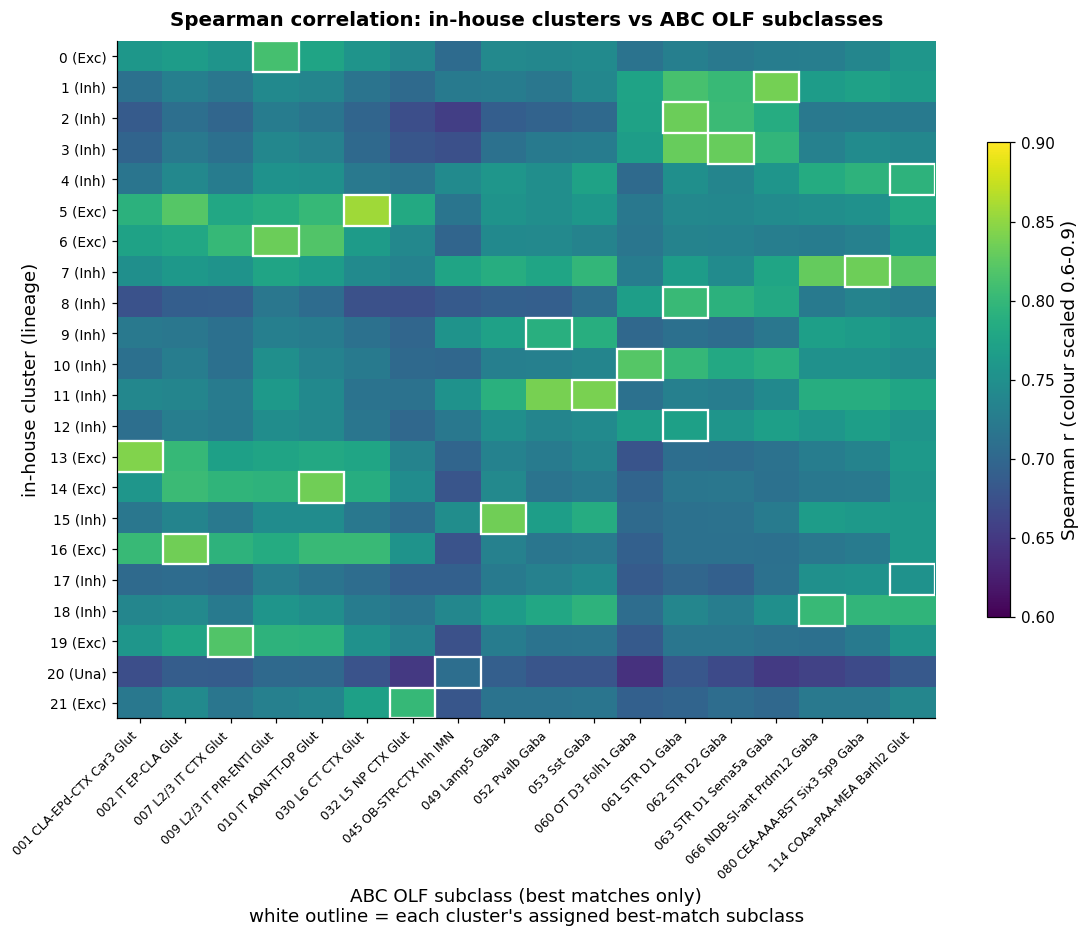

In [7]:
# Restrict the columns to subclasses that are a best match for at least one cluster, so the
# heatmap is a readable ~15 columns rather than all 50, and box each cluster's assigned subclass.
row_order = sorted(corr.index, key=int)
best_subclasses = sorted(assign["best_subclass"].unique())
cm = corr.loc[row_order, best_subclasses]

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(cm.values, aspect="auto", cmap=ps.SEQUENTIAL, vmin=0.6, vmax=0.9)
ax.set_yticks(range(len(cm.index)))
ax.set_yticklabels([f"{c} ({assign.loc[c, 'inhouse_call'][:3]})" for c in cm.index], fontsize=9)
ax.set_xticks(range(len(cm.columns)))
ax.set_xticklabels(cm.columns, rotation=45, ha="right", fontsize=8)

for yi, c in enumerate(cm.index):
    xi = list(cm.columns).index(assign.loc[c, "best_subclass"])
    ax.add_patch(plt.Rectangle((xi - 0.5, yi - 0.5), 1, 1, fill=False,
                               edgecolor="white", lw=1.5))

ax.set_xlabel("ABC OLF subclass (best matches only)\nwhite outline = each cluster's assigned best-match subclass")
ax.set_ylabel("in-house cluster (lineage)")
ax.set_title("Spearman correlation: in-house clusters vs ABC OLF subclasses", pad=10)
cbar = fig.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label("Spearman r (colour scaled 0.6-0.9)")
ps.save_fig(fig, FIG_DIR / "reference_concordance_heatmap", close=False)
plt.show()

In [8]:
# Marker fractions for the large discordant cluster (leiden 4), so the neurotransmitter and
# region-identity percentages cited in the interpretation trace to a committed output. VGLUT1 is Slc17a7.
disc_counts = adata.layers["counts"]
disc_mask = (adata.obs["leiden"].astype(str) == "4").values
n_disc = int(disc_mask.sum())
print(f"Discordant cluster leiden 4: {n_disc} nuclei")
for gene, label in [("Gad2", "Gad2"), ("Slc17a7", "VGLUT1 (Slc17a7)"),
                    ("Foxp2", "Foxp2"), ("Meis2", "Meis2")]:
    j = adata.var_names.get_loc(gene)
    expr = int(np.asarray((disc_counts[disc_mask, :][:, j] > 0).sum()).ravel()[0])
    print(f"  {label:16s} expressing in {expr / n_disc:.0%} of leiden-4 nuclei")

Discordant cluster leiden 4: 3877 nuclei
  Gad2             expressing in 58% of leiden-4 nuclei
  VGLUT1 (Slc17a7) expressing in 15% of leiden-4 nuclei
  Foxp2            expressing in 80% of leiden-4 nuclei
  Meis2            expressing in 92% of leiden-4 nuclei


## Interpretation

The in-house excitatory / inhibitory annotation agrees with independent Allen ABC Atlas labels for
**19 of 21 neuronal clusters (90%)**, covering **88% of neuronal nuclei** (28,563 / 32,615). The
Glut/GABA adjusted Rand index of 0.64 is driven almost entirely by one large discordant cluster
rather than by widespread disagreement. Two caveats:

- Two clusters are discordant. The larger (3,877 nuclei, leiden 4) is one of the biggest clusters
  in the dataset, not a tiny population. It is GABAergic by its markers (Gad2 in 58% of nuclei,
  VGLUT1 in 15%, from the fractions above) while its top-correlating ABC subclass is glutamatergic
  (Spearman 0.79), a correlation artifact where the reference lacks a matched AON GABAergic type.
  Its olfactory-tubercle and ventral-striatal identity (Foxp2 in 80%, Meis2 in 92%) explains the
  match to an amygdalar glutamatergic subclass it does not truly resemble. The second (175 nuclei,
  leiden 17) is cholinergic and has the weakest reference match of any annotated cluster
  (Spearman 0.75).
- The largest inhibitory clusters map to **striatal and olfactory-tubercle GABAergic subclasses**
  (striatal D1/D2, olfactory-tubercle D3, CEA-AAA-BST), while smaller clusters match
  pan-telencephalic interneuron types (Pvalb, Sst, Lamp5) and a basal-forebrain type. This
  independently corroborates the dissection-scope caveat raised in the clustering and methods notes,
  with the large inhibitory fraction reflecting the AON abutting GABAergic-rich olfactory tubercle /
  ventral striatal tissue.